In [ ]:
"""
房地产市场洞察与市场评估



"""

In [1]:
# 1.导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']

In [63]:
# 2.导入数据
df = pd.read_csv('house_sales.csv')


In [6]:
# 3.数据概览
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
df.head(5)
df.info()

总记录数： 106118
字段数量： 12
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


In [64]:
# 4.数据清洗
# 删除无用的列
df.drop(columns='origin_url',inplace=True)

In [93]:
# 检查是否有缺失值
df.dropna(inplace=True)



In [92]:
# 检查是否有重复值
df.drop_duplicates(inplace=True)
df.head(5)

# 面积的数据类型转换
df['area'] = df['area'].str.replace('㎡','').astype(float)

# 售价的数据类型转换
df['price'] = df['price'].str.replace('万','').astype(float)

# 单位
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)


# 朝向的数据类型转换
df['toward'] = df['toward'].astype('category')

# 建造年份的数据类型转换
df['year'] = df['year'].str.replace('年建','').astype(int)

AttributeError: Can only use .str accessor with string values, not floating

In [67]:
# 异常值的处理

# 面积的异常值处理
df = df[(df['area'] < 600) & (df['area'] > 20)]


# 房屋售价的异常处理 IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5 * IQR
high_price = Q3 + 1.5 * IQR

df = df[(df['price'] > low_price) & (df['price'] < high_price)]

In [90]:
# 5.新数据特征构造

# 地区
df['district'] = df['address'].str.split('-').str[0]
# 楼层
df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')

def fun1(str1):
    if '低' in str1:
        return '底楼层'
    if'中' in str1:
        return '中楼层'
    if'高' in str1:
        return '高楼层'
    return '未知'

df['floor_type2'] = df['floor'].apply(fun1).astype('category')

# 是否是直辖市
def fun2(str2):
    if str2 in ['北京','上海','天津','重庆']:
        return 1
    else:
        return 0
df['zxs'] = df['city'].apply(fun2)

# 卧室的数量
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
# 客厅的数量
# df['livingrooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)

df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)

# 楼龄
df['building_age'] = 2025 - df['year']


# 价格的分段
df['price_labels'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])

df

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_type2,zxs,bedrooms,livingrooms,building_age,price_labels
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.00,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222元/㎡,2013,龙岗,中层,中楼层,0,3,2,12,中价
2,合肥,生态公园-淮海大道与大众路交口,95.00,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895元/㎡,2019,生态公园,中层,中楼层,0,3,2,6,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.00,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649元/㎡,2017,撮镇,中层,中楼层,0,2,1,8,低价
6,合肥,龙岗-长江东路与和县里交口,50.00,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200元/㎡,2019,龙岗,高层,高楼层,0,2,1,6,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.00,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167元/㎡,2012,新亚汽车站,中层,中楼层,0,4,2,13,高价
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106080,广元,万达广场-雪峰,61.11,中层（共6层）,富康小区,37.0,四川,2室2厅,南北向,6055元/㎡,2012,万达广场,中层,中楼层,0,2,2,13,低价
106082,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,89.94,中层（共26层）,南郡,73.0,四川,2室2厅,南向,8117元/㎡,2016,万达广场,中层,中楼层,0,2,2,9,低价
106084,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,85.00,高层（共25层）,南郡,75.0,四川,2室1厅,南向,8824元/㎡,2016,万达广场,高层,高楼层,0,2,1,9,低价
106086,广元,利州广场-广元市利州区兴安路519号,85.00,低层（共18层）,御景湾,86.0,四川,2室2厅,西南向,10118元/㎡,2015,利州广场,低层,底楼层,0,2,2,10,中价


                 price      area      unit  building_age
price         1.000000  0.452523  0.742731      0.091520
area          0.452523  1.000000 -0.164320     -0.083923
unit          0.742731 -0.164320  1.000000      0.199128
building_age  0.091520 -0.083923  0.199128      1.000000
unit            0.742731
area            0.452523
building_age    0.091520
Name: price, dtype: float64


<Axes: >

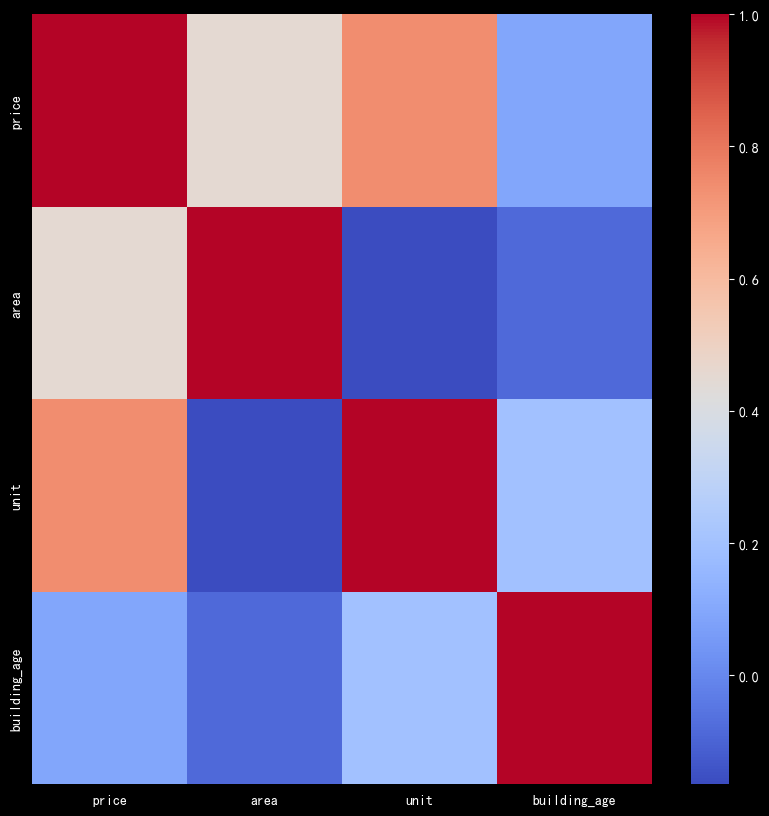

In [106]:
# 6.问题分析以及可视化
"""
问题编号：A1
问题：哪些变量最影响放假？面积，楼层，房间数那个影响更大
分析主题：特征相关性
分析目标：了解房屋各特征性对房价的线性影响
分组字段：无
指标/方法：皮尔逊相关系数
"""

# 选择数值型特征

a = df[['price','area','unit','building_age']].corr() # 相关系数
print(a)
# 对放假的影响最大的几个因素的排序
print(a['price'].sort_values(ascending=False)[1:])
# 热力图
plt.figure(figsize=(10,10))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')

In [107]:
"""
问题编号：A2
问题：全国房价总体分布是怎么样的？是否存在极端
分析主题：描述性统计
分析目标：概览数值型字段的分布特征
分组字段：无
指标/方法：平均数/中位数/四分位数/标准差
"""
df.describe()

,area,price,unit,year,zxs,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,11.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,2.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,8.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,10.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,14.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,49.000000


(array([ 991., 4810., 6499., 4613., 3362., 2226., 1333., 1055.,  691.,
         555.]),
 array([  9. ,  38.7,  68.4,  98.1, 127.8, 157.5, 187.2, 216.9, 246.6,
        276.3, 306. ]),
 <BarContainer object of 10 artists>)

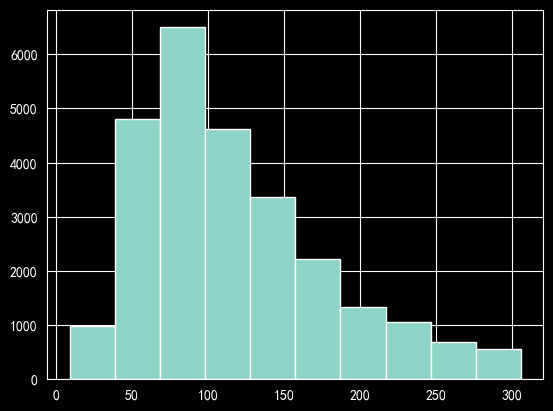

In [116]:
# 房价分布直方图
plt.subplot(111)
plt.hist(df['price'],bins=10)

<Axes: xlabel='price', ylabel='Count'>

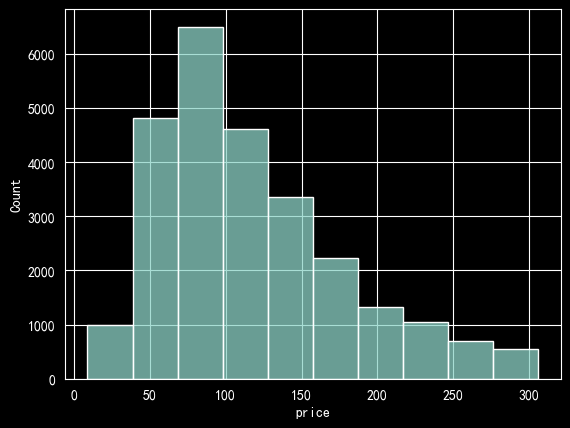

In [117]:
sns.histplot(data=df,x='price',bins=10)

In [121]:
"""
问题编号：A6
问题：南北向是否真的比单一朝向贵，贵多少
分析主题：朝向溢价
分析目标：toward
指标/方法：方差分析/多重比较
"""

df['toward'].value_counts()


res = df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'median',
    'building_age':'mean',
})
res.reset_index(inplace=True)
res

toward       price            unit building_age
                mean median   median         mean
0    东北向  114.555333  100.0  12198.0    12.609524
1    东南向  115.542608  105.0  10864.0    10.951745
2     东向  110.158568   95.0  11421.0    12.761337
3    东西向   98.935099   82.0   9000.0    15.490066
4     北向   92.527907   75.5  11698.0    13.108527
5    南北向  119.472147  104.5  10000.0    12.073703
6     南向  114.555016  103.0  10759.0    11.551160
7    西北向  119.107594  105.0  12290.0    13.473684
8    西南向  139.711811  138.4  13333.0    13.452756
9     西向  102.662298   86.0  12528.0    13.385093

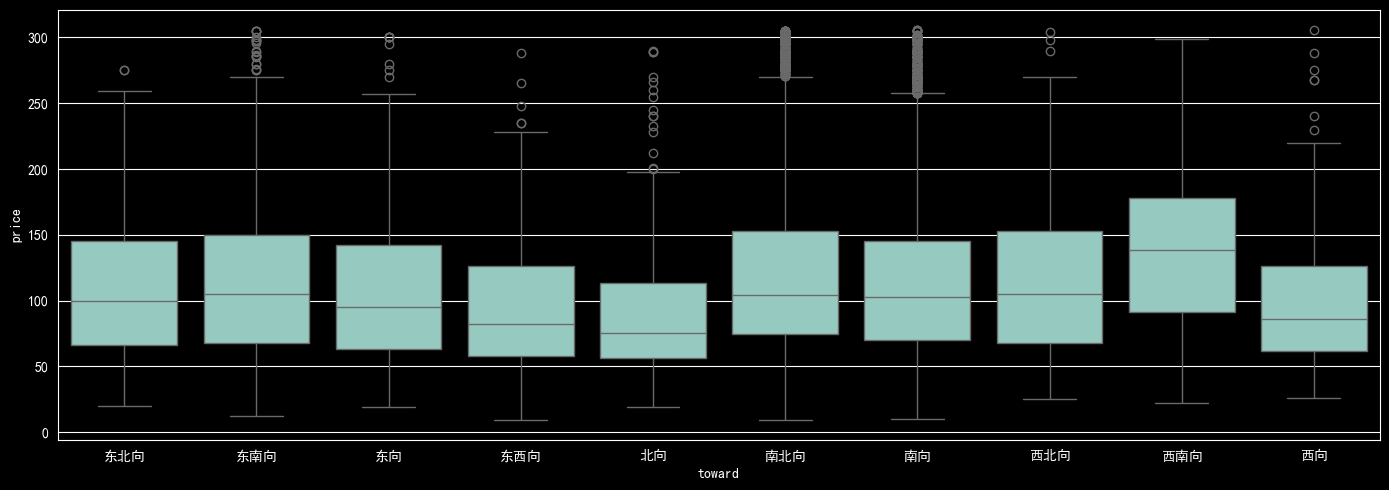

In [123]:
# 数据可视化
plt.figure(figsize=(14,5))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout()